Narrow binaries: 2449
Wide binaries: 35
popt_w: 31.12177446594854


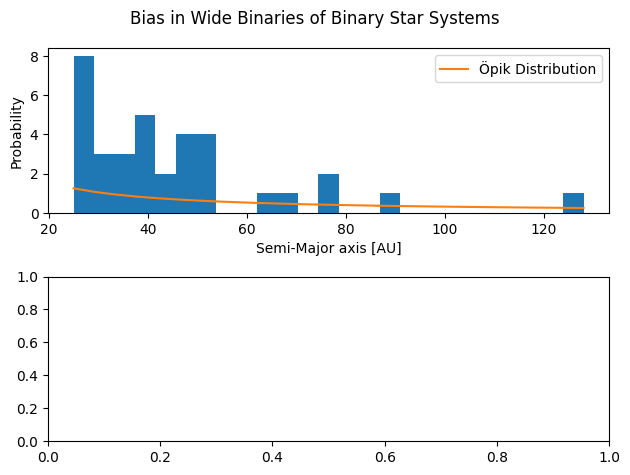

popt_n: [0.47140164 0.41811303]


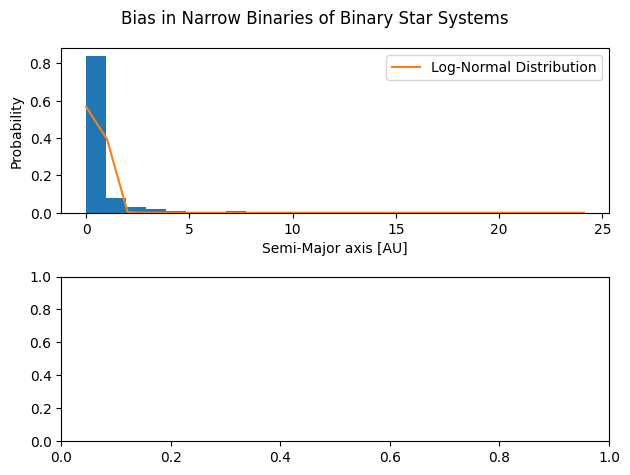

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.optimize import curve_fit

def öpik_law(C, a):
    'Distribution for wide binaries'
    N = C*(1/a)
    return N
def log_normal_dist(a, sigma, mu):
    'Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((a-mu)/sigma)**2)/2)
    return N
def normal_dist(a, sigma, mu):
    'Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((np.log(a)-mu)/sigma)**2)/2)
    return N
reduced_raw_data = pd.read_csv(r'DATA\RAW\reduced_raw_data.csv')
reduced_raw_data_clean = reduced_raw_data[reduced_raw_data['a'].notna()]
sma_data = reduced_raw_data_clean['a']

narrow_binaries = sma_data[sma_data <= 25]
wide_binaries = sma_data[sma_data >= 25]

print(f'Narrow binaries: {len(narrow_binaries)}')
print(f'Wide binaries: {len(wide_binaries)}')

n_bins_w = 25
counts_w, bins_w = np.histogram(wide_binaries, bins=n_bins_w, density=False)
centers_w = (bins_w[:-1] + bins_w[1:]) / 2

popt_w, pcov_w = curve_fit(öpik_law, xdata=centers_w[counts_w > 0], ydata=counts_w[counts_w > 0])
x_w = np.linspace(min(bins_w), max(bins_w), n_bins_w)
print(f'popt_w: {popt_w[0]}')

fig, axes = plt.subplots(2,1)
axes[0].hist(wide_binaries, bins=n_bins_w, density=False)
axes[0].plot(x_w, öpik_law(C=popt_w[0], a=x_w), label='Öpik Distribution')
axes[0].set_ylabel('Probability')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Wide Binaries of Binary Star Systems')
plt.tight_layout()
plt.show()

n_bins_n = 25
counts_n, bins_n = np.histogram(narrow_binaries, bins=n_bins_n, density=True)
centers_n = (bins_n[:-1] + bins_n[1:]) / 2

popt_n, pcov_n = curve_fit(log_normal_dist, xdata=centers_n[counts_n > 0], ydata=counts_n[counts_n > 0])
x_n = np.linspace(min(bins_n), max(bins_n), n_bins_n)
print(f'popt_n: {popt_n}')

fig, axes = plt.subplots(2,1)
axes[0].hist(narrow_binaries, bins=n_bins_n, density=True)
axes[0].plot(x_n, log_normal_dist(sigma=popt_n[0], mu=popt_n[1], a=x_n), label='Log-Normal Distribution')
axes[0].set_ylabel('Probability')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Narrow Binaries of Binary Star Systems')
plt.tight_layout()
plt.show()